In [6]:
import pandas as pd
import os

# O dataset foi baixado para o caminho contido na variável `path`
# Assumindo que o arquivo CSV principal é 'netflix_titles.csv' dentro desse diretório.

data_file_path = os.path.join(path, 'netflix_titles.csv')

df_netflix = pd.read_csv(data_file_path)

# Exibe as primeiras 5 linhas do DataFrame para você ter uma ideia dos dados.
display(df_netflix.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# The dataset typically contains a 'netflix_titles.csv' file.
file_path = "netflix_titles.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shivamb/netflix-shows",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_8706/3884540554.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'netflix-shows' dataset.
First 5 records:   show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1

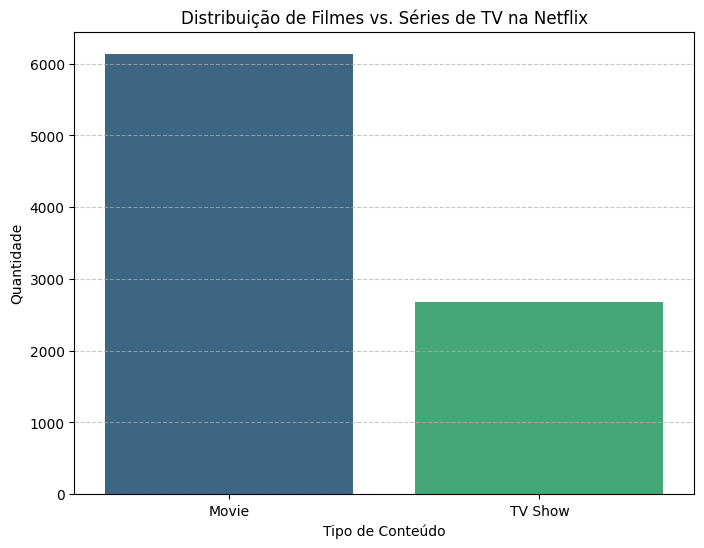

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar a quantidade de Filmes e Séries de TV
content_type_counts = df_netflix['type'].value_counts().reset_index()
content_type_counts.columns = ['Content Type', 'Count']

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x='Content Type', y='Count', data=content_type_counts, palette='viridis', hue='Content Type', legend=False)
plt.title('Distribuição de Filmes vs. Séries de TV na Netflix')
plt.xlabel('Tipo de Conteúdo')
plt.ylabel('Quantidade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
print('Informações do DataFrame df_netflix:')
df_netflix.info()

print('\nContagem de valores ausentes por coluna:')
display(df_netflix.isnull().sum())

Informações do DataFrame df_netflix:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Contagem de valores ausentes por coluna:


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [12]:
productions_per_year = df_netflix.groupby('release_year').size().reset_index(name='count')
display(productions_per_year.sort_values(by='release_year', ascending=False).head())

,release_year,count
73,2021,592
72,2020,953
71,2019,1030
70,2018,1147
69,2017,1032


### Gráfico Interativo: Produções por Ano e Distribuição de Tipo de Conteúdo

Vamos criar duas visualizações interativas usando Plotly para analisar:
1.  **Tendência de Lançamento:** Número de filmes/séries lançados por ano.
2.  **Distribuição de Conteúdo:** Proporção entre Filmes e Séries de TV.

In [13]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Gráfico de Linha Interativo para Produções por Ano
fig_year = px.line(productions_per_year, x='release_year', y='count', title='Número de Produções Lançadas por Ano na Netflix')
fig_year.update_traces(mode='lines+markers')
fig_year.show()

In [14]:
# 2. Gráfico de Barras Interativo para Distribuição de Tipo de Conteúdo
fig_type = px.bar(content_type_counts, x='Content Type', y='Count', title='Distribuição de Filmes vs. Séries de TV na Netflix', color='Content Type')
fig_type.show()

Estas são as duas primeiras visualizações interativas! Você gostaria de combiná-las em um único dashboard, ou adicionar mais visualizações como conteúdo por país, diretores mais populares, etc.?

### Dashboard Interativo Combinado

Vamos unir o gráfico de linha de produções por ano e o gráfico de barras de distribuição de conteúdo em uma única figura interativa.

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Criar subplots: 1 linha, 3 colunas
fig_combined = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Número de Produções Lançadas por Ano na Netflix',
        'Distribuição de Filmes vs. Séries de TV na Netflix',
        'Distribuição da Duração dos Filmes na Netflix'
    )
)

# Adicionar o gráfico de linha de produções por ano
fig_combined.add_trace(
    go.Scatter(x=productions_per_year['release_year'], y=productions_per_year['count'], mode='lines+markers', name='Produções por Ano', marker_color='blue'),
    row=1, col=1
)

# Adicionar o gráfico de barras de distribuição de tipo de conteúdo
# Encontrar as contagens de Filmes e Séries de TV
movie_count = content_type_counts[content_type_counts['Content Type'] == 'Movie']['Count'].iloc[0]
tv_show_count = content_type_counts[content_type_counts['Content Type'] == 'TV Show']['Count'].iloc[0]

fig_combined.add_trace(
    go.Bar(x=['Filme'], y=[movie_count], name='Filme', marker_color='purple'),
    row=1, col=2
)
fig_combined.add_trace(
    go.Bar(x=['Série de TV'], y=[tv_show_count], name='Série de TV', marker_color='green'),
    row=1, col=2
)

# Adicionar o histograma da duração dos filmes
fig_combined.add_trace(
    go.Histogram(x=df_movies['duration_minutes'], nbinsx=30, name='Duração de Filmes', marker_color='orange'),
    row=1, col=3
)

# Ajustar layout e títulos gerais
fig_combined.update_layout(
    title_text='Dashboard Netflix: Tendências de Lançamento, Distribuição de Conteúdo e Duração de Filmes',
    height=450, # Ajuste a altura para melhor visualização dos 3 gráficos
    showlegend=True # Mostra a legenda combinada para todos os gráficos
)

# Ajustar títulos dos eixos para cada subplot
fig_combined.update_xaxes(title_text='Ano de Lançamento', row=1, col=1)
fig_combined.update_yaxes(title_text='Número de Produções', row=1, col=1)

fig_combined.update_xaxes(title_text='Tipo de Conteúdo', row=1, col=2)
fig_combined.update_yaxes(title_text='Quantidade', row=1, col=2)

fig_combined.update_xaxes(title_text='Duração (minutos)', row=1, col=3)
fig_combined.update_yaxes(title_text='Número de Filmes', row=1, col=3)

fig_combined.show()

Aqui está o dashboard combinado! Você pode interagir com ambos os gráficos na mesma visualização. Gostaria de adicionar mais análises ou este dashboard atende à sua necessidade por enquanto?

In [18]:
import plotly.express as px

# Criar o histograma da duração dos filmes
fig_duration_hist = px.histogram(df_movies, x='duration_minutes',
                                 nbins=30, # Número de "barras" no histograma
                                 title='Distribuição da Duração dos Filmes na Netflix',
                                 labels={'duration_minutes': 'Duração (minutos)', 'count': 'Número de Filmes'})

fig_duration_hist.update_layout(xaxis_title='Duração (minutos)', yaxis_title='Número de Filmes')
fig_duration_hist.show()

Aqui está o histograma interativo mostrando a distribuição da duração dos filmes! Você pode passar o mouse sobre as barras para ver detalhes. Isso ajuda a identificar a faixa de duração mais comum para os filmes na Netflix.

Agora, você gostaria de integrar este histograma ao dashboard combinado, criar um dashboard separado para análises de duração, ou explorar outras visualizações?

In [17]:
# Filtrar o DataFrame para apenas filmes
df_movies = df_netflix[df_netflix['type'] == 'Movie'].copy()

# Remover linhas com valores ausentes na coluna 'duration' antes de processar
df_movies = df_movies.dropna(subset=['duration'])

# Remover ' min' da coluna 'duration' e converter para numérico
df_movies['duration_minutes'] = df_movies['duration'].str.replace(' min', '').astype(int)

# Calcular a duração média dos filmes
average_movie_duration = df_movies['duration_minutes'].mean()

print(f"A duração média dos filmes na Netflix é de: {average_movie_duration:.2f} minutos.")

A duração média dos filmes na Netflix é de: 99.58 minutos.


Agora que temos a duração média dos filmes, você gostaria de adicioná-la ao dashboard existente, talvez como um texto descritivo ou uma nova visualização, ou prefere criar um gráfico separado para isso?

Agora que temos uma ideia das colunas e dos dados ausentes, quais são os principais tópicos ou perguntas que você gostaria de responder com seu dashboard? Por exemplo, você estaria interessado em:

*   **Distribuição de conteúdo** (Filmes vs. Programas de TV)
*   **Conteúdo por país** (Países com mais produções)
*   **Tendências ao longo do tempo** (Número de adições por ano/mês)
*   **Diretores/Atores mais populares**
*   **Duração de filmes ou temporadas de séries**

Com base nas suas preferências, posso ajudar a construir as visualizações para o dashboard!

In [2]:
import kagglehub
path = kagglehub.dataset_download("shivamb/netflix-shows")

Using Colab cache for faster access to the 'netflix-shows' dataset.
